## Imports

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import os
import sys
import matplotlib.pyplot as plt

os.chdir("/home/patrick/ansermodelling")

from models.FFNN_network import FFNN
from data.anser_dataset import *
from models.train import *



## Dataset

In [2]:
train_loader, val_loader = make_dataloaders("data/dataset.npz")

In [3]:
model = FFNN(input_dim=8, output_dim=6, hidden_dims=[256,256,256])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)
loss_fn = PoseLoss()

In [6]:
%%time
history = train(model, train_loader, val_loader, optimizer, scheduler = scheduler, epochs=200, loss_fn = loss_fn, print_losses = True, log_path = "models/train_log.json")

epoch 	 LR 	 Training Loss 	 Test Loss 	 e_p test 	 e_n test
1 	 9.98e-04 	 0.0025 	  0.0025 	 24.3386 	 11.9352
2 	 9.98e-04 	 0.0024 	  0.0023 	 22.3983 	 11.5945
3 	 9.97e-04 	 0.0023 	  0.0025 	 26.5258 	 11.5548
4 	 9.96e-04 	 0.0021 	  0.0020 	 21.5447 	 10.7696
5 	 9.95e-04 	 0.0021 	  0.0022 	 23.9129 	 10.8612
6 	 9.94e-04 	 0.0020 	  0.0022 	 24.0919 	 10.7180
7 	 9.93e-04 	 0.0020 	  0.0019 	 20.8473 	 10.1160
8 	 9.91e-04 	 0.0019 	  0.0019 	 19.7968 	 10.0454
9 	 9.90e-04 	 0.0020 	  0.0020 	 22.2434 	 10.4175
10 	 9.88e-04 	 0.0019 	  0.0018 	 20.5130 	 9.2644
11 	 9.86e-04 	 0.0018 	  0.0018 	 20.3400 	 10.2023
12 	 9.84e-04 	 0.0018 	  0.0018 	 21.0796 	 9.9419
13 	 9.82e-04 	 0.0018 	  0.0017 	 19.5841 	 9.2301
14 	 9.80e-04 	 0.0017 	  0.0018 	 22.6488 	 9.3579
15 	 9.78e-04 	 0.0017 	  0.0018 	 21.3700 	 9.5984
16 	 9.76e-04 	 0.0017 	  0.0021 	 21.4945 	 10.6847
17 	 9.73e-04 	 0.0017 	  0.0019 	 20.1374 	 10.3917
18 	 9.70e-04 	 0.0016 	  0.0019 	 21.9555 	 9.6802


In [7]:
torch.save(model.state_dict(), "models/nn_normal.pt")

In [18]:
epochs = [h['epoch'] for h in history]
train_loss = [h['train_loss'] for h in history]
test_loss = [h['test_loss'] for h in history]
e_p = [h['e_p_mean'] for h in history]
e_n = [h['e_n_mean'] for h in history]

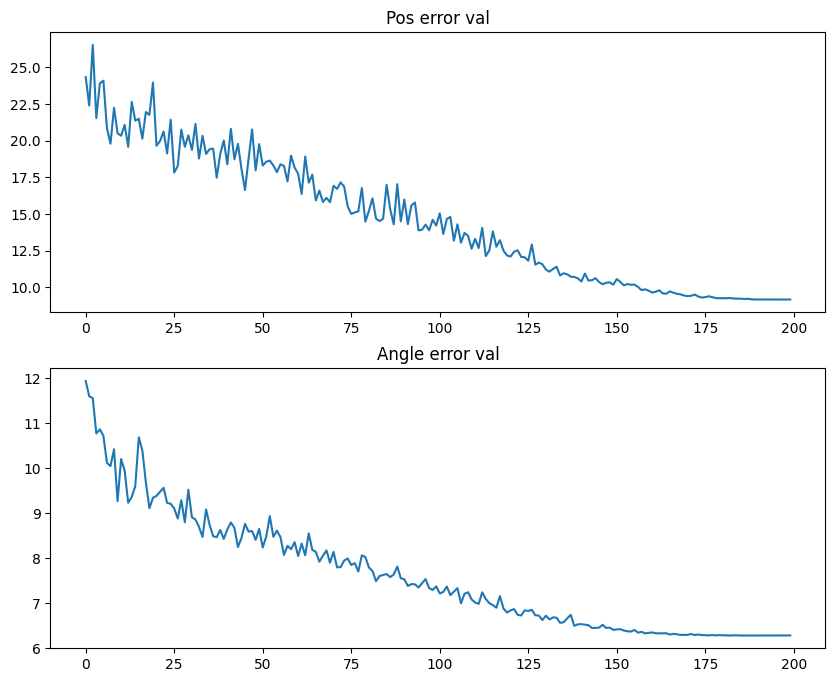

In [22]:
fig, axes = plt.subplots(2,figsize=(10, 8))
axes[0].plot(e_p)
axes[0].set_title("Pos error val")
axes[1].plot(e_n)
axes[1].set_title("Angle error val")
plt.show()
